# Parte 2 — MC-JEPA sobre V-JEPA2: Frozen y Partial Fine-tune

```
Videos InHARD → DataLoader → V-JEPA2 (preentrenado)
                                  │
                     ┌────────────┴────────────┐
               Congelado               Últimas capas desc.
                  │                           │
             Tokens [B,N,D]           Tokens [B,N,D] + grad
                  │                           │
           MC-JEPA Head ──────────── MC-JEPA Head
          (short/mid/global)       (short/mid/global)
           ┌────┴──────┐            ┌────┴──────┐
       Predictor   Clasificador  Predictor   Clasificador
           │           │             │           │
       Loss JEPA  Loss CE        Loss JEPA  Loss CE
           └─────┬─────┘             └─────┬─────┘
           Loss total                Loss total
     VJEPA2_MCJEPA_frozen      VJEPA2_MCJEPA_partial_finetune
                  └──────────┬──────────┘
                     Suavizado probs
               (No · SMA · EMA · Adaptive EMA)
                             │
              Accuracy · F1w · F1m · Loss cls · Loss JEPA
```

## 0 · Instalación

In [13]:
!pip install -q --no-cache-dir \
    "huggingface_hub==0.35.3" \
    "tokenizers>=0.21,<0.22" \
    "safetensors>=0.4.5" \
    "accelerate>=0.34.0" \
    timm einops decord opencv-python matplotlib scikit-learn tqdm pandas
!pip install -q --no-cache-dir git+https://github.com/huggingface/transformers.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 kB 113.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 335.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.10.0.dev0 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.35.3 which is incompatible.
transformers 5.10.0.dev0 requires tokenizers<=0.23.0,>=0.22.0, but you have tokenizers 0.21.4 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 124.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 184.2 MB/s eta 0:00:00


## 1 · Imports y configuración

In [14]:
import os, cv2, json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from collections import deque
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, adjusted_rand_score,
    normalized_mutual_info_score, silhouette_score
)
from sklearn.cluster import KMeans
from transformers import AutoModel, AutoVideoProcessor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# ── Configuración ──────────────────────────────────────────────────────────
INHARD_ROOT    = Path("/content/drive/MyDrive/01-InHARD/Segmented")
CHECKPOINT_DIR = Path("/content/drive/MyDrive/MC_JEPA_INHARD_CHECKPOINTS")

NUM_FRAMES  = 64
IMAGE_SIZE  = 224
BATCH_SIZE  = 8
VIDEO_EXTS  = {".mp4", ".avi", ".mov", ".mkv"}
HF_MODEL_ID = "facebook/vjepa2-vitl-fpc64-256"

DEVICE: cuda


## 2 · Google Drive y Hugging Face

In [15]:
from google.colab import drive
drive.mount('/content/drive')

from huggingface_hub import login
from getpass import getpass
login(token=getpass("Token de Hugging Face: "))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Token de Hugging Face: ··········


## 3 · Dataset InHARD → DataLoader

In [16]:
def read_video_frames(path, num_frames=8, image_size=224):
    cap = cv2.VideoCapture(str(path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release(); raise ValueError(f"Sin frames: {path}")
    idxs = np.linspace(0, total - 1, num_frames).astype(int)
    frames = []
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, f = cap.read()
        if not ok: continue
        frames.append(Image.fromarray(cv2.cvtColor(
            cv2.resize(f, (image_size, image_size)), cv2.COLOR_BGR2RGB)))
    cap.release()
    if not frames: raise ValueError(f"Sin frames extraídos: {path}")
    while len(frames) < num_frames: frames.append(frames[-1].copy())
    return frames[:num_frames]


class InHARDVideoDataset(Dataset):
    def __init__(self, samples, class_to_idx, num_frames=8, image_size=224):
        self.samples      = samples
        self.class_to_idx = class_to_idx
        idx2c = {v: k for k, v in class_to_idx.items()}
        self.classes    = [idx2c[i] for i in range(len(idx2c))]
        self.num_frames = num_frames
        self.image_size = image_size
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            frames = read_video_frames(path, self.num_frames, self.image_size)
        except Exception:
            frames = [Image.new("RGB", (self.image_size, self.image_size))] * self.num_frames
        return {"frames": frames, "label": label, "path": str(path)}

def collate_fn(batch):
    return (
        [b["frames"] for b in batch],
        torch.tensor([b["label"] for b in batch], dtype=torch.long),
        [b["path"] for b in batch]
    )

def build_inhard_splits(root, num_frames=8, image_size=224,
                         test_size=0.15, val_size=0.15, random_state=42):
    videos = sorted([p for p in Path(root).rglob("*") if p.suffix.lower() in VIDEO_EXTS])
    labels_text = [p.parent.name for p in videos]
    classes = sorted(set(labels_text))
    c2i     = {c: i for i, c in enumerate(classes)}
    labels  = [c2i[c] for c in labels_text]
    samples = list(zip(videos, labels))
    tv, ts = train_test_split(samples, test_size=test_size, random_state=random_state, stratify=labels)
    tv_l = [l for _, l in tv]
    tr, vl = train_test_split(tv, test_size=val_size/(1-test_size), random_state=random_state, stratify=tv_l)
    mk = lambda s: InHARDVideoDataset(s, c2i, num_frames, image_size)
    return mk(tr), mk(vl), mk(ts), classes, c2i

train_ds, val_ds, test_ds, classes, class_to_idx = build_inhard_splits(
    INHARD_ROOT, num_frames=NUM_FRAMES, image_size=IMAGE_SIZE)
NUM_CLASSES = len(classes)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f"NUM_CLASSES={NUM_CLASSES} | Train={len(train_ds)} | Val={len(val_ds)} | Test={len(test_ds)}")
print("Clases:", train_ds.classes)

NUM_CLASSES=14 | Train=3711 | Val=796 | Test=796
Clases: ['Assemble system', 'Consult sheets', 'No action', 'Picking in front', 'Picking left', 'Put down component', 'Put down measuring rod', 'Put down screwdriver', 'Put down subsystem', 'Take component', 'Take measuring rod', 'Take screwdriver', 'Take subsystem', 'Turn sheets']


## 4 · Cargar V-JEPA2 preentrenado

In [17]:
print(f"Cargando V-JEPA2: {HF_MODEL_ID}")
vjepa2_processor = AutoVideoProcessor.from_pretrained(HF_MODEL_ID, trust_remote_code=True)
vjepa2_enc = AutoModel.from_pretrained(HF_MODEL_ID, trust_remote_code=True).to(DEVICE)
vjepa2_enc.eval()
for p in vjepa2_enc.parameters():
    p.requires_grad = False
print("V-JEPA2 cargado y congelado por defecto.")

Cargando V-JEPA2: facebook/vjepa2-vitl-fpc64-256


Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

V-JEPA2 cargado y congelado por defecto.


## 5 · Control de congelamiento de V-JEPA2

In [18]:
def freeze_vjepa2():
    """Congela todos los parámetros de V-JEPA2."""
    for p in vjepa2_enc.parameters():
        p.requires_grad = False
    vjepa2_enc.eval()
    print("V-JEPA2 congelado.")


def unfreeze_last_vjepa2_layers(num_last_layers=2):
    """
    Descongela las últimas `num_last_layers` capas/bloques de V-JEPA2.
    Detecta índices de bloques automáticamente por nombre de parámetro.
    """
    freeze_vjepa2()

    names = [n for n, _ in vjepa2_enc.named_parameters()]
    block_indices = []
    for n in names:
        for part in n.replace(".", " ").split():
            if part.isdigit():
                block_indices.append(int(part))

    if not block_indices:
        # Fallback: descongelar últimos N*20 parámetros
        params = list(vjepa2_enc.named_parameters())
        for _, p in params[-num_last_layers * 20:]:
            p.requires_grad = True
        print(f"Fallback: últimos {num_last_layers*20} parámetros descongelados.")
        return

    max_block = max(block_indices)
    min_unfreeze = max_block - num_last_layers + 1
    count = 0
    for name, p in vjepa2_enc.named_parameters():
        toks = name.replace(".", " ").split()
        found = None
        for t in toks:
            if t.isdigit(): found = int(t)
        if found is not None and found >= min_unfreeze:
            p.requires_grad = True
            count += p.numel()

    print(f"Descongelados bloques {min_unfreeze}–{max_block} | "
          f"Parámetros entrenables V-JEPA2: {count:,}")


def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 6 · Forward V-JEPA2 → tokens latentes

In [19]:
def pil_to_numpy_videos(batch_frames):
    return [np.stack([np.array(img.convert("RGB")) for img in vf]) for vf in batch_frames]


def normalize_vjepa2_output(outputs):
    """Extrae tensor de tokens [B, N, D] de cualquier formato de salida."""
    if hasattr(outputs, "last_hidden_state"):
        t = outputs.last_hidden_state
    elif isinstance(outputs, tuple):
        t = outputs[0]
    elif isinstance(outputs, dict):
        for key in ("last_hidden_state", "x_norm_patchtokens"):
            if key in outputs: t = outputs[key]; break
        else:
            t = list(outputs.values())[0]
    else:
        t = outputs

    if t.ndim == 2:   t = t.unsqueeze(1)
    elif t.ndim == 4:
        B, T, N, D = t.shape; t = t.reshape(B, T * N, D)
    return t   # [B, N, D]


def vjepa2_forward_tokens(batch_frames, require_grad=False):
    """
    Extrae tokens latentes de V-JEPA2.
    - require_grad=False : sin gradiente (V-JEPA2 congelado)
    - require_grad=True  : con gradiente (partial fine-tune)
    """
    videos = pil_to_numpy_videos(batch_frames)
    inputs = vjepa2_processor(videos=videos, return_tensors="pt")
    inputs = {k: v.to(DEVICE) if torch.is_tensor(v) else v for k, v in inputs.items()}

    ctx = torch.enable_grad() if require_grad else torch.no_grad()
    with ctx:
        try:
            outputs = vjepa2_enc(**inputs, skip_predictor=True)
        except TypeError:
            outputs = vjepa2_enc(**inputs)

    return normalize_vjepa2_output(outputs)   # [B, N, D]


# Detectar D_VJEPA2
_fb, _lb, _pb = next(iter(train_loader))
with torch.no_grad():
    _tokens = vjepa2_forward_tokens(_fb, require_grad=False)
D_VJEPA2 = _tokens.shape[-1]
print(f"Tokens shape: {_tokens.shape} | D_VJEPA2={D_VJEPA2}")

Tokens shape: torch.Size([8, 8192, 1024]) | D_VJEPA2=1024


## 7 · MC-JEPA Head

Arquitectura interna:
- **Proyección**: `Linear(D_vjepa2 → hidden)`
- **3 encoders Transformer**: short, mid, global
- **Fusión**: concatena short + mid → `Linear → hidden`
- **Predictor JEPA**: predice `z_global` a partir del contexto
- **Clasificador**: produce logits de clase

In [20]:
class MCJEPAHead(nn.Module):
    """
    Head que opera sobre tokens V-JEPA2.

    Flujo:
        tokens [B, N, D_vjepa2]
            │
            proj → [B, N, hidden]
            │
        ┌───┼───────────────────┐
      short_enc             mid_enc         global_enc
      x[:, -N//4:]          x[:, -N//2:]    x
        └──── pool ──────── pool ──────── pool
              z_short       z_mid          z_global
                 │              │
              cat([z_short, z_mid]) → fusion → z_context
                                                    │
                                      ┌─────────────┤
                                 predictor      classifier
                                      │              │
                               z_pred_global      logits
    """
    def __init__(self, d_in, hidden=256, nhead=4, layers=1, num_classes=14):
        super().__init__()
        self.proj = nn.Linear(d_in, hidden)

        self.short_encoder  = self._mk_enc(hidden, nhead, layers)
        self.mid_encoder    = self._mk_enc(hidden, nhead, layers)
        self.global_encoder = self._mk_enc(hidden, nhead, layers)

        # Fusión contexto corto + medio
        self.fusion = nn.Sequential(
            nn.LayerNorm(hidden * 2),
            nn.Linear(hidden * 2, hidden),
            nn.GELU(),
            nn.Dropout(0.2)
        )

        # Predictor JEPA: z_context → z_global estimado
        self.predictor = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden)
        )

        # Clasificador
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, num_classes)
        )

    def _mk_enc(self, h, n, l):
        return nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=h, nhead=n, dim_feedforward=h * 4,
                dropout=0.1, batch_first=True, activation="gelu"),
            num_layers=l)

    def forward(self, tokens):
        """
        tokens: [B, N, D_vjepa2]
        Devuelve dict con logits, z_context, z_pred_global, z_global.
        """
        x = self.proj(tokens)   # [B, N, hidden]
        B, N, _ = x.shape
        sl, ml = max(1, N // 4), max(1, N // 2)

        z_short  = self.short_encoder(x[:, -sl:]).mean(1)    # contexto corto
        z_mid    = self.mid_encoder(x[:, -ml:]).mean(1)       # contexto medio
        z_global = self.global_encoder(x).mean(1)             # contexto global

        z_context      = self.fusion(torch.cat([z_short, z_mid], dim=-1))
        z_pred_global  = self.predictor(z_context)     # predicción de z_global
        logits         = self.classifier(z_context)

        return {
            "logits":        logits,          # [B, num_classes]
            "z_context":     z_context,        # [B, hidden]
            "z_pred_global": z_pred_global,    # [B, hidden]  ← predicción
            "z_global":      z_global          # [B, hidden]  ← target
        }

## 8 · Funciones de entrenamiento y evaluación

In [21]:
def train_mcjepa_epoch(head, loader, optimizer,
                       lambda_jepa=0.3, finetune_vjepa2=False, max_batches=None):
    """
    Un epoch de entrenamiento.
    Loss total = Loss_CE  +  lambda_jepa * Loss_JEPA
    Loss_JEPA  = MSE(z_pred_global, z_global.detach())
    """
    head.train()
    vjepa2_enc.train() if finetune_vjepa2 else vjepa2_enc.eval()

    losses, cls_l, jepa_l = [], [], []
    y_true, y_pred = [], []

    for i, (frames, labels, _) in enumerate(tqdm(loader, desc="train")):
        if max_batches and i >= max_batches: break
        labels = labels.to(DEVICE)

        tokens = vjepa2_forward_tokens(frames, require_grad=finetune_vjepa2)
        out    = head(tokens)

        loss_cls  = F.cross_entropy(out["logits"], labels)
        loss_jepa = F.mse_loss(out["z_pred_global"], out["z_global"].detach())
        loss      = loss_cls + lambda_jepa * loss_jepa

        optimizer.zero_grad(); loss.backward(); optimizer.step()

        losses.append(loss.item()); cls_l.append(loss_cls.item()); jepa_l.append(loss_jepa.item())
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(out["logits"].argmax(1).detach().cpu().numpy())

    return {
        "loss":       float(np.mean(losses)),
        "loss_cls":   float(np.mean(cls_l)),
        "loss_jepa":  float(np.mean(jepa_l)),
        "accuracy":   accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted",
                                labels=list(range(NUM_CLASSES)), zero_division=0)
    }


@torch.no_grad()
def evaluate_mcjepa(head, loader, lambda_jepa=0.3, max_batches=None):
    head.eval(); vjepa2_enc.eval()
    losses, cls_l, jepa_l = [], [], []
    y_true, y_pred, embeddings = [], [], []

    for i, (frames, labels, _) in enumerate(tqdm(loader, desc="eval")):
        if max_batches and i >= max_batches: break
        labels = labels.to(DEVICE)
        tokens = vjepa2_forward_tokens(frames, require_grad=False)
        out    = head(tokens)

        loss_cls  = F.cross_entropy(out["logits"], labels)
        loss_jepa = F.mse_loss(out["z_pred_global"], out["z_global"].detach())
        loss      = loss_cls + lambda_jepa * loss_jepa

        losses.append(loss.item()); cls_l.append(loss_cls.item()); jepa_l.append(loss_jepa.item())
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(out["logits"].argmax(1).cpu().numpy())
        embeddings.append(out["z_context"].detach().cpu())

    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return {
        "loss":       float(np.mean(losses)),
        "loss_cls":   float(np.mean(cls_l)),
        "loss_jepa":  float(np.mean(jepa_l)),
        "accuracy":   accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted",
                                labels=list(range(NUM_CLASSES)), zero_division=0),
        "f1_macro":   f1_score(y_true, y_pred, average="macro",
                               labels=list(range(NUM_CLASSES)), zero_division=0),
        "report":     classification_report(y_true, y_pred, labels=list(range(NUM_CLASSES)),
                                            target_names=train_ds.classes, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))),
        "y_true": y_true, "y_pred": y_pred,
        "embeddings": torch.cat(embeddings).numpy()
    }

## 9 · Función de experimento MC-JEPA

In [22]:
def run_mcjepa_experiment(
    experiment_name,
    finetune_vjepa2=False,
    unfreeze_last_layers=2,
    epochs=3,
    lr_head=1e-3,
    lr_backbone=1e-5,
    lambda_jepa=0.3,
    max_batches_train=15,
    max_batches_val=5,
    max_batches_test=5
):
    """
    Entrena MC-JEPA Head sobre V-JEPA2.

    finetune_vjepa2=False → V-JEPA2 completamente congelado
    finetune_vjepa2=True  → últimas `unfreeze_last_layers` capas descongeladas
    """
    print("\n" + "="*80)
    print(f"EXPERIMENTO: {experiment_name}")
    print(f"  finetune_vjepa2={finetune_vjepa2}  |  lambda_jepa={lambda_jepa}")
    print("="*80)

    # ── Configurar congelamiento ──────────────────────────────────────────────
    if finetune_vjepa2:
        unfreeze_last_vjepa2_layers(unfreeze_last_layers)
    else:
        freeze_vjepa2()

    # ── Crear head ────────────────────────────────────────────────────────────
    head = MCJEPAHead(d_in=D_VJEPA2, hidden=256, nhead=4, layers=1,
                      num_classes=NUM_CLASSES).to(DEVICE)

    # ── Optimizador ───────────────────────────────────────────────────────────
    if finetune_vjepa2:
        backbone_params = [p for p in vjepa2_enc.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW([
            {"params": head.parameters(),     "lr": lr_head},
            {"params": backbone_params,        "lr": lr_backbone}
        ], weight_decay=1e-4)
    else:
        optimizer = torch.optim.AdamW(head.parameters(), lr=lr_head, weight_decay=1e-4)

    print(f"  Head params: {count_trainable(head):,}")
    print(f"  V-JEPA2 trainable params: {count_trainable(vjepa2_enc):,}")

    # ── Loop de entrenamiento ─────────────────────────────────────────────────
    best_val_f1, best_head_state, best_backbone_state = -1, None, None
    history = []

    for epoch in range(1, epochs + 1):
        tr = train_mcjepa_epoch(head, train_loader, optimizer,
                                lambda_jepa=lambda_jepa,
                                finetune_vjepa2=finetune_vjepa2,
                                max_batches=max_batches_train)
        vl = evaluate_mcjepa(head, val_loader, lambda_jepa=lambda_jepa,
                              max_batches=max_batches_val)

        history.append({
            "experiment": experiment_name, "epoch": epoch,
            "train_loss": tr["loss"], "train_loss_cls": tr["loss_cls"],
            "train_loss_jepa": tr["loss_jepa"], "train_f1": tr["f1_weighted"],
            "val_loss": vl["loss"], "val_loss_cls": vl["loss_cls"],
            "val_loss_jepa": vl["loss_jepa"], "val_f1": vl["f1_weighted"]
        })
        print(f"  Epoch {epoch:02d} | "
              f"train_f1={tr['f1_weighted']:.4f}  val_f1={vl['f1_weighted']:.4f} | "
              f"loss_cls={tr['loss_cls']:.4f}  loss_jepa={tr['loss_jepa']:.4f}")

        if vl["f1_weighted"] > best_val_f1:
            best_val_f1 = vl["f1_weighted"]
            best_head_state = {k: v.detach().cpu().clone() for k, v in head.state_dict().items()}
            if finetune_vjepa2:
                best_backbone_state = {k: v.detach().cpu().clone()
                                       for k, v in vjepa2_enc.state_dict().items()}

    # ── Restaurar mejor checkpoint ────────────────────────────────────────────
    head.load_state_dict({k: v.to(DEVICE) for k, v in best_head_state.items()})
    if finetune_vjepa2 and best_backbone_state:
        vjepa2_enc.load_state_dict({k: v.to(DEVICE) for k, v in best_backbone_state.items()})

    # ── Evaluación final en test ───────────────────────────────────────────────
    test_metrics = evaluate_mcjepa(head, test_loader, lambda_jepa=lambda_jepa,
                                    max_batches=max_batches_test)
    print(f"\n  TEST  acc={test_metrics['accuracy']:.4f}  "
          f"f1_w={test_metrics['f1_weighted']:.4f}  "
          f"loss_cls={test_metrics['loss_cls']:.4f}  "
          f"loss_jepa={test_metrics['loss_jepa']:.4f}")
    print(test_metrics["report"])

    return {
        "experiment": experiment_name,
        "head": head,
        "history": pd.DataFrame(history),
        "test_metrics": test_metrics
    }

## 10 · Correr los dos experimentos

In [23]:
training_results = {}

# ── 1. V-JEPA2 congelado + MC-JEPA ────────────────────────────────────────────
training_results["VJEPA2_MCJEPA_frozen"] = run_mcjepa_experiment(
    experiment_name   = "VJEPA2_MCJEPA_frozen",
    finetune_vjepa2   = False,
    epochs            = 3,
    lr_head           = 1e-3,
    lambda_jepa       = 0.3,
    max_batches_train = 15,
    max_batches_val   = 3,
    max_batches_test  = 3
)

# ── 2. Últimas capas V-JEPA2 descongeladas + MC-JEPA ──────────────────────────
training_results["VJEPA2_MCJEPA_partial_finetune"] = run_mcjepa_experiment(
    experiment_name     = "VJEPA2_MCJEPA_partial_finetune",
    finetune_vjepa2     = True,
    unfreeze_last_layers= 2,
    epochs              = 3,
    lr_head             = 5e-4,
    lr_backbone         = 1e-6,
    lambda_jepa         = 0.3,
    max_batches_train   = 15,
    max_batches_val     = 5,
    max_batches_test    = 5
)

print("\nExperimentos completados:", list(training_results.keys()))


EXPERIMENTO: VJEPA2_MCJEPA_frozen
  finetune_vjepa2=False  |  lambda_jepa=0.3
V-JEPA2 congelado.
  Head params: 2,966,030
  V-JEPA2 trainable params: 0


train:   0%|          | 0/464 [00:00<?, ?it/s]

eval:   0%|          | 0/100 [00:00<?, ?it/s]

  Epoch 01 | train_f1=0.0852  val_f1=0.2045 | loss_cls=2.4809  loss_jepa=0.3137


train:   0%|          | 0/464 [00:00<?, ?it/s]

...

train:   0%|          | 0/464 [00:00<?, ?it/s]

eval:   0%|          | 0/100 [00:00<?, ?it/s]

  Epoch 03 | train_f1=0.1200  val_f1=0.1186 | loss_cls=2.4290  loss_jepa=0.0430


eval:   0%|          | 0/100 [00:00<?, ?it/s]


  TEST  acc=0.2500  f1_w=0.1000  loss_cls=2.3991  loss_jepa=0.1321
                        precision    recall  f1-score   support

       Assemble system       0.25      1.00      0.40        10
        Consult sheets       0.00      0.00      0.00         0
             No action       0.00      0.00      0.00         2
      Picking in front       0.00      0.00      0.00         2
          Picking left       0.00      0.00      0.00        10
    Put down component       0.00      0.00      0.00         3
Put down measuring rod       0.00      0.00      0.00         2
  Put down screwdriver       0.00      0.00      0.00         3
    Put down subsystem       0.00      0.00      0.00         2
        Take component       0.00      0.00      0.00         3
    Take measuring rod       0.00      0.00      0.00         0
      Take screwdriver       0.00      0.00      0.00         2
        Take subsystem       0.00      0.00      0.00         0
           Turn sheets       0.00  

## 11 · Curvas de entrenamiento

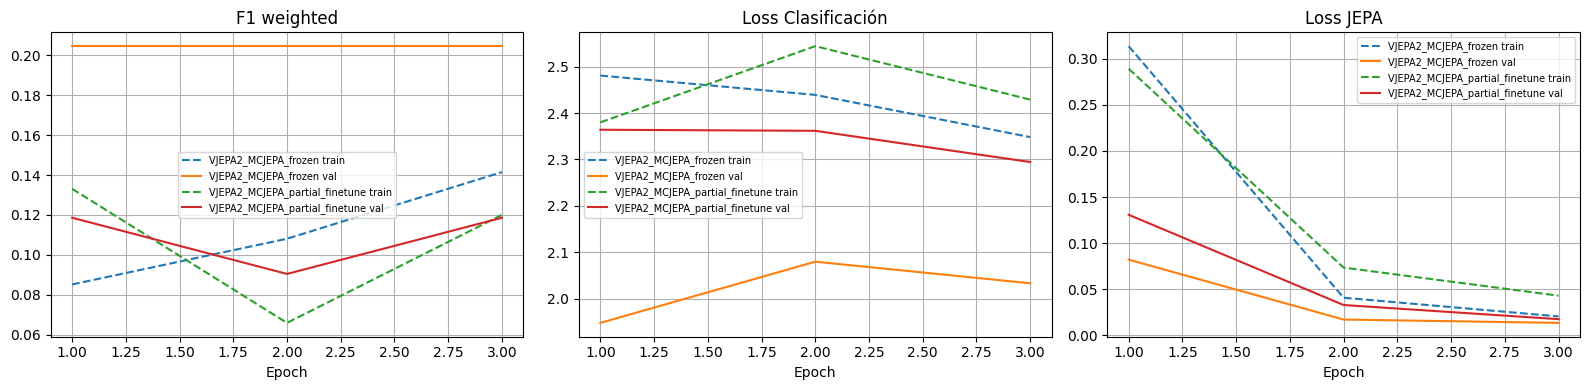

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metrics = [("train_f1", "val_f1", "F1 weighted"),
           ("train_loss_cls", "val_loss_cls", "Loss Clasificación"),
           ("train_loss_jepa", "val_loss_jepa", "Loss JEPA")]

for ax, (tr_key, vl_key, title) in zip(axes, metrics):
    for name, result in training_results.items():
        hist = result["history"]
        ax.plot(hist["epoch"], hist[tr_key], label=f"{name} train", linestyle="--")
        ax.plot(hist["epoch"], hist[vl_key], label=f"{name} val")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.grid(True)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 12 · Resumen de métricas en test

In [25]:
rows = []
for name, result in training_results.items():
    m = result["test_metrics"]
    rows.append({
        "experiment":  name,
        "accuracy":    m["accuracy"],
        "f1_weighted": m["f1_weighted"],
        "f1_macro":    m["f1_macro"],
        "loss_cls":    m["loss_cls"],
        "loss_jepa":   m["loss_jepa"]
    })

summary_df = pd.DataFrame(rows).sort_values("f1_weighted", ascending=False)
summary_df

,experiment,accuracy,f1_weighted,f1_macro,loss_cls,loss_jepa
0,VJEPA2_MCJEPA_frozen,0.25,0.1,0.028571,2.224108,0.081053
1,VJEPA2_MCJEPA_partial_finetune,0.25,0.1,0.028571,2.399056,0.132074


## 13 · Suavizadores de probabilidades

In [26]:
class NoSmoother:
    def reset(self): pass
    def update(self, p): return p

class SMASmoother:
    def __init__(self, w=5): self.buf = deque(maxlen=w)
    def reset(self): self.buf.clear()
    def update(self, p):
        self.buf.append(p)
        s = np.mean(np.stack(self.buf), axis=0); return s / s.sum()

class EMASmoother:
    def __init__(self, alpha=0.35): self.a = alpha; self.s = None
    def reset(self): self.s = None
    def update(self, p):
        self.s = p.copy() if self.s is None else self.a * p + (1-self.a) * self.s
        self.s /= self.s.sum(); return self.s

class AdaptiveEMASmoother:
    def __init__(self, a_min=0.15, a_max=0.75, thr=0.55):
        self.a_min=a_min; self.a_max=a_max; self.thr=thr; self.s=None
    def reset(self): self.s = None
    def update(self, p):
        c = float(np.max(p))
        a = self.a_min if c < self.thr else self.a_min + (self.a_max - self.a_min) * c
        self.s = p.copy() if self.s is None else a * p + (1-a) * self.s
        self.s /= self.s.sum(); return self.s

def make_smoothers():
    return {
        "No_smoothing":  NoSmoother(),
        "SMA_probs":     SMASmoother(w=5),
        "EMA_probs":     EMASmoother(alpha=0.35),
        "Adaptive_EMA":  AdaptiveEMASmoother()
    }

print("Suavizadores: No_smoothing · SMA_probs · EMA_probs · Adaptive_EMA")

Suavizadores: No_smoothing · SMA_probs · EMA_probs · Adaptive_EMA


## 14 · Evaluación final con suavizado

In [27]:
@torch.no_grad()
def get_logits_from_head(head, loader, max_batches=None):
    head.eval(); vjepa2_enc.eval()
    all_logits, all_labels = [], []
    for i, (frames, labels, _) in enumerate(tqdm(loader, desc="logits")):
        if max_batches and i >= max_batches: break
        tokens = vjepa2_forward_tokens(frames, require_grad=False)
        logits = head(tokens)["logits"]
        all_logits.extend(logits.cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_logits), np.array(all_labels)


def eval_with_smoothing(logits, labels, num_classes, class_names):
    probs_all = F.softmax(torch.tensor(logits), dim=-1).numpy()
    results = {}
    for sname, smoother in make_smoothers().items():
        smoother.reset()
        y_pred = [int(np.argmax(smoother.update(p))) for p in probs_all]
        y_true = labels.tolist()
        results[sname] = {
            "accuracy":    accuracy_score(y_true, y_pred),
            "f1_weighted": f1_score(y_true, y_pred, average="weighted",
                                    labels=list(range(num_classes)), zero_division=0),
            "f1_macro":    f1_score(y_true, y_pred, average="macro",
                                    labels=list(range(num_classes)), zero_division=0),
            "report": classification_report(y_true, y_pred, labels=list(range(num_classes)),
                                            target_names=class_names, zero_division=0),
            "confusion_matrix": confusion_matrix(y_true, y_pred, labels=list(range(num_classes))),
            "y_true": np.array(y_true), "y_pred": np.array(y_pred)
        }
    return results


# ── Correr ────────────────────────────────────────────────────────────────────
all_rows = []
MAX_BATCHES_EVAL = 10

for exp_name, result in training_results.items():
    print(f"\nEvaluando suavizado: {exp_name}")
    logits, labels = get_logits_from_head(result["head"], test_loader, MAX_BATCHES_EVAL)
    sm_results = eval_with_smoothing(logits, labels, NUM_CLASSES, train_ds.classes)
    for sname, m in sm_results.items():
        all_rows.append({
            "model":       exp_name,
            "smoothing":   sname,
            "accuracy":    m["accuracy"],
            "f1_weighted": m["f1_weighted"],
            "f1_macro":    m["f1_macro"]
        })

final_df = pd.DataFrame(all_rows).sort_values(["f1_weighted", "accuracy"], ascending=False)
final_df


Evaluando suavizado: VJEPA2_MCJEPA_frozen


logits:   0%|          | 0/100 [00:00<?, ?it/s]


Evaluando suavizado: VJEPA2_MCJEPA_partial_finetune


logits:   0%|          | 0/100 [00:00<?, ?it/s]

,model,smoothing,accuracy,f1_weighted,f1_macro
0,VJEPA2_MCJEPA_frozen,No_smoothing,0.225,0.082653,0.026239
1,VJEPA2_MCJEPA_frozen,SMA_probs,0.225,0.082653,0.026239
2,VJEPA2_MCJEPA_frozen,EMA_probs,0.225,0.082653,0.026239
3,VJEPA2_MCJEPA_frozen,Adaptive_EMA,0.225,0.082653,0.026239
4,VJEPA2_MCJEPA_partial_finetune,No_smoothing,0.225,0.082653,0.026239
5,VJEPA2_MCJEPA_partial_finetune,SMA_probs,0.225,0.082653,0.026239
6,VJEPA2_MCJEPA_partial_finetune,EMA_probs,0.225,0.082653,0.026239
7,VJEPA2_MCJEPA_partial_finetune,Adaptive_EMA,0.225,0.082653,0.026239


## 15 · Gráficas comparativas

F1 weighted × suavizado


smoothing,Adaptive_EMA,EMA_probs,No_smoothing,SMA_probs
model,,,,
VJEPA2_MCJEPA_frozen,0.082653,0.082653,0.082653,0.082653
VJEPA2_MCJEPA_partial_finetune,0.082653,0.082653,0.082653,0.082653



Accuracy × suavizado


smoothing,Adaptive_EMA,EMA_probs,No_smoothing,SMA_probs
model,,,,
VJEPA2_MCJEPA_frozen,0.225,0.225,0.225,0.225
VJEPA2_MCJEPA_partial_finetune,0.225,0.225,0.225,0.225


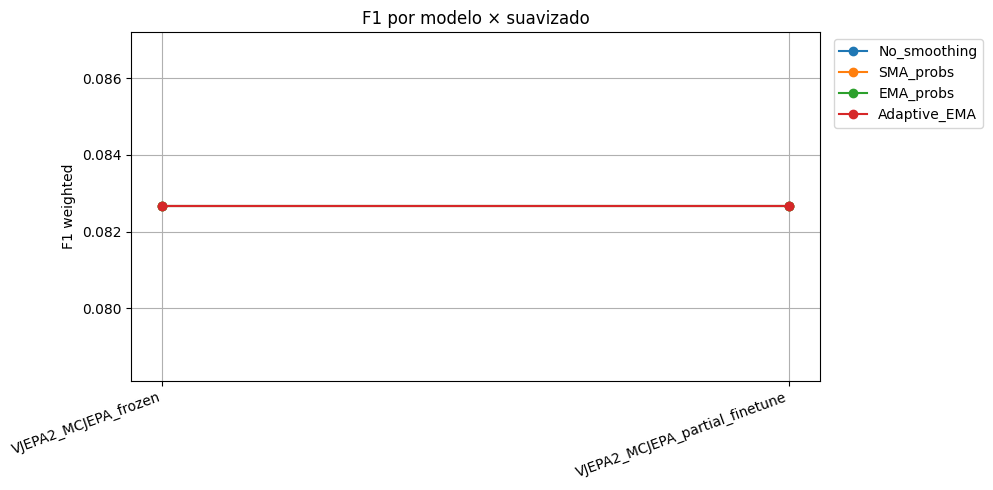

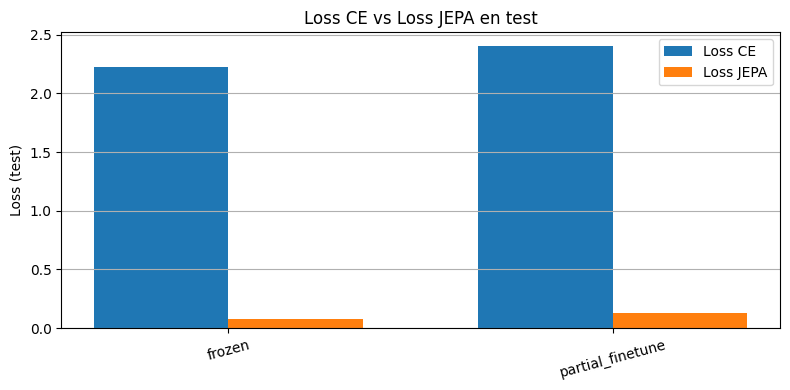


Métricas de clustering:


,model,ARI,NMI,Silhouette
0,VJEPA2_MCJEPA_frozen,0.041667,0.667550,0.102459
1,VJEPA2_MCJEPA_partial_finetune,0.036952,0.526101,0.098181


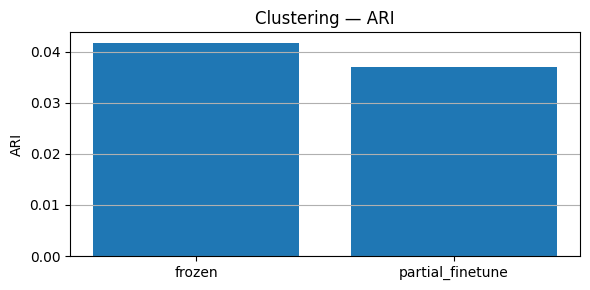

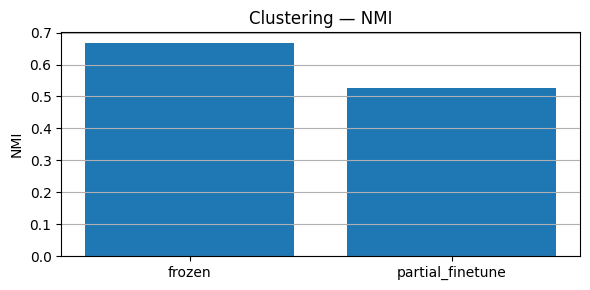

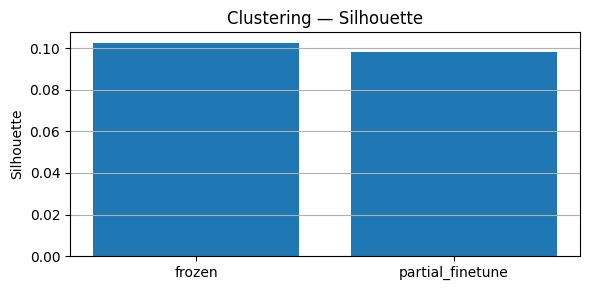

In [28]:
# ── Tablas pivote ─────────────────────────────────────────────────────────────

f1_pivot  = final_df.pivot_table(index="model", columns="smoothing", values="f1_weighted")
acc_pivot = final_df.pivot_table(index="model", columns="smoothing", values="accuracy")
print("F1 weighted × suavizado"); display(f1_pivot)
print("\nAccuracy × suavizado");  display(acc_pivot)

# ── Líneas F1 ─────────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 5))
for sname in final_df["smoothing"].unique():
    df_s = final_df[final_df["smoothing"] == sname]
    plt.plot(df_s["model"], df_s["f1_weighted"], marker="o", label=sname)
plt.xticks(rotation=20, ha="right")
plt.ylabel("F1 weighted"); plt.title("F1 por modelo × suavizado")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left"); plt.grid(True)
plt.tight_layout(); plt.show()

# ── Barras losses (frozen vs partial) ─────────────────────────────────────────

names = list(training_results.keys())
loss_cls_vals  = [training_results[n]["test_metrics"]["loss_cls"]  for n in names]
loss_jepa_vals = [training_results[n]["test_metrics"]["loss_jepa"] for n in names]
x = np.arange(len(names)); w = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, loss_cls_vals,  w, label="Loss CE")
ax.bar(x + w/2, loss_jepa_vals, w, label="Loss JEPA")
ax.set_xticks(x); ax.set_xticklabels([n.replace("VJEPA2_MCJEPA_","") for n in names], rotation=15)
ax.set_ylabel("Loss (test)"); ax.set_title("Loss CE vs Loss JEPA en test")
ax.legend(); ax.grid(axis="y"); plt.tight_layout(); plt.show()

# ── Clustering sobre embeddings entrenados ────────────────────────────────────

cluster_rows = []
for name, result in training_results.items():
    m  = result["test_metrics"]
    X, y = m["embeddings"], m["y_true"]
    km = KMeans(n_clusters=NUM_CLASSES, random_state=42, n_init="auto").fit_predict(X)
    cluster_rows.append({
        "model": name,
        "ARI":        adjusted_rand_score(y, km),
        "NMI":        normalized_mutual_info_score(y, km),
        "Silhouette": silhouette_score(X, km) if len(set(km)) > 1 else np.nan
    })

cluster_df = pd.DataFrame(cluster_rows)
print("\nMétricas de clustering:")
display(cluster_df)

for metric in ["ARI", "NMI", "Silhouette"]:
    plt.figure(figsize=(6, 3))
    plt.bar([r.replace("VJEPA2_MCJEPA_","") for r in cluster_df["model"]], cluster_df[metric])
    plt.title(f"Clustering — {metric}"); plt.ylabel(metric); plt.grid(axis="y")
    plt.tight_layout(); plt.show()

## 16 · Mejor configuración final

In [29]:
best = final_df.iloc[0]
print("MEJOR CONFIGURACIÓN")
print("=" * 45)
print(f"  Modelo:      {best['model']}")
print(f"  Suavizado:   {best['smoothing']}")
print(f"  Accuracy:    {best['accuracy']:.4f}")
print(f"  F1 weighted: {best['f1_weighted']:.4f}")
print(f"  F1 macro:    {best['f1_macro']:.4f}")
m = training_results[best["model"]]["test_metrics"]
print(f"  Loss cls:    {m['loss_cls']:.4f}")
print(f"  Loss JEPA:   {m['loss_jepa']:.4f}")

MEJOR CONFIGURACIÓN
  Modelo:      VJEPA2_MCJEPA_frozen
  Suavizado:   No_smoothing
  Accuracy:    0.2250
  F1 weighted: 0.0827
  F1 macro:    0.0262
  Loss cls:    2.2241
  Loss JEPA:   0.0811


## 17 · Guardar checkpoints

In [30]:
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
partial_dir = CHECKPOINT_DIR / "vjepa2_mcjepa_experiments"
partial_dir.mkdir(parents=True, exist_ok=True)

for name, result in training_results.items():
    torch.save({
        "experiment_name": name,
        "head_state_dict": result["head"].state_dict(),
        "D_VJEPA2": D_VJEPA2,
        "hidden": 256, "nhead": 4, "layers": 1,
        "num_classes": NUM_CLASSES,
        "class_names": train_ds.classes,
        "history": result["history"].to_dict()
    }, partial_dir / f"{name}.pt")
print("Checkpoints MC-JEPA guardados.")

# Tablas CSV
final_df.to_csv(CHECKPOINT_DIR / "parte2_smoothing_results.csv", index=False)
summary_df.to_csv(CHECKPOINT_DIR / "parte2_test_summary.csv", index=False)
f1_pivot.to_csv(CHECKPOINT_DIR / "parte2_f1_pivot.csv")
cluster_df.to_csv(CHECKPOINT_DIR / "parte2_clustering.csv", index=False)

print("Tablas CSV guardadas.")
print("\nTodo guardado en:", CHECKPOINT_DIR)

Checkpoints MC-JEPA guardados.
Tablas CSV guardadas.

Todo guardado en: /content/drive/MyDrive/MC_JEPA_INHARD_CHECKPOINTS
